# Table 5 — Meteorological Context (Meteostat)

**Script file:** `Paper1_Table5_meteorological_context.ipynb`

**หมายเหตุ:** เทียบสถานีที่ resolve ได้กับ Table 5 ในต้นฉบับ (Pakchong Agromet / Ban Pang Asok) ก่อนใช้แทน

**สิ่งที่ต้องเตรียมก่อนรัน:** ไฟล์ `บันทึกการตรวจวัดปริมาณฝุ่น.xlsx` (ข้อมูลภาคสนามต้นฉบับ 32 จุด)


In [1]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 0 - Setup
!pip install requests openpyxl meteostat==1.6.8 -q

In [2]:
import re, time, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import openpyxl
from datetime import datetime

plt.rcParams['figure.dpi'] = 120

## 1. อัปโหลดไฟล์ข้อมูลภาคสนามต้นฉบับ

In [3]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 1 - Load raw field data
from google.colab import files
uploaded = files.upload()  # เลือกไฟล์ "บันทึกการตรวจวัดปริมาณฝุ่น.xlsx"
RAW_XLSX = list(uploaded.keys())[0]
print("อัปโหลดไฟล์แล้ว:", RAW_XLSX)

Saving บันทึกการตรวจวัดปริมาณฝุ่น.xlsx to บันทึกการตรวจวัดปริมาณฝุ่น.xlsx
อัปโหลดไฟล์แล้ว: บันทึกการตรวจวัดปริมาณฝุ่น.xlsx


In [4]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 1 - Parse raw field data (name, address, link, PM2.5, TPM, date)
wb = openpyxl.load_workbook(RAW_XLSX, data_only=True)
ws = wb['Sheet1']

records = {}
order = []
for row in ws.iter_rows(min_row=3, max_row=1001, values_only=True):
    name = row[0]
    if not name:
        continue
    if name not in records:
        records[name] = {
            'name': name, 'url': row[1], 'address': row[2],
            'pm25': row[6], 'tpm': row[9], 'date': str(row[13]),
        }
        order.append(name)

sites_raw = [records[n] for n in order]
print(f"จำนวนจุดตรวจวัดทั้งหมด: {len(sites_raw)}")
assert len(sites_raw) == 32, "คาดว่าจะมี 32 จุด - ตรวจสอบไฟล์ต้นฉบับถ้าไม่ตรง"

จำนวนจุดตรวจวัดทั้งหมด: 32


## 2. Resolve พิกัด GPS จากลิงก์ Google Maps

ต้องรันบน Colab (ต้องมีอินเทอร์เน็ตเปิด) เพราะ short link (`goo.gl/maps/...`) ต้องไล่ตาม redirect

In [5]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 2 - Resolve GPS coordinates from Google Maps short links
PATTERNS = [
    re.compile(r"!3d(-?\d+\.\d+)!4d(-?\d+\.\d+)"),
    re.compile(r"@(-?\d+\.\d+),(-?\d+\.\d+)"),
    re.compile(r"[?&]q=(-?\d+\.\d+),(-?\d+\.\d+)"),
    re.compile(r"ll=(-?\d+\.\d+),(-?\d+\.\d+)"),
]

def extract_latlon(url_or_text):
    for pat in PATTERNS:
        m = pat.search(url_or_text)
        if m:
            return float(m.group(1)), float(m.group(2))
    return None, None

def resolve_link(short_url, timeout=15):
    try:
        r = requests.get(short_url, allow_redirects=True, timeout=timeout,
                          headers={'User-Agent': 'Mozilla/5.0'})
        lat, lon = extract_latlon(r.url)
        if lat is None:
            lat, lon = extract_latlon(r.text[:5000])
        return lat, lon
    except Exception:
        return None, None

for i, s in enumerate(sites_raw, 1):
    lat, lon = resolve_link(s['url'])
    s['lat'], s['lon'] = lat, lon
    print(f"[{i:02d}/32] {s['name']}: {'OK' if lat else 'FAILED - resolve manually'}")
    time.sleep(0.4)

missing = [s['name'] for s in sites_raw if s['lat'] is None]
if missing:
    print("\nจุดที่ resolve ไม่สำเร็จ (ต้องเติมพิกัดด้วยมือ):", missing)
else:
    print("\nพิกัดครบทั้ง 32 จุด")

[01/32] จุดตรวจวัดอากาศ-1: OK
[02/32] จุดตรวจวัดอากาศ-2: OK
[03/32] จุดตรวจวัดอากาศ-3: OK
[04/32] จุดตรวจวัดอากาศ-4: OK
[05/32] จุดตรวจวัดอากาศ-5: OK
[06/32] จุดตรวจวัดอากาศ-6: OK
[07/32] จุดตรวจวัดอากาศ-7: OK
[08/32] จุดตรวจวัดอากาศ-8: OK
[09/32] จุดตรวจวัดอากาศ-9: OK
[10/32] จุดตรวจวัดอากาศ-10: OK
[11/32] จุดตรวจวัดอากาศ-11: OK
[12/32] จุดตรวจวัดอากาศ-12: OK
[13/32] จุดตรวจวัดอากาศ-13: OK
[14/32] จุดตรวจวัดอากาศ-14: OK
[15/32] จุดตรวจวัดอากาศ-15: OK
[16/32] จุดตรวจวัดอากาศ-16: OK
[17/32] จุดตรวจวัดอากาศ-17: OK
[18/32] จุดตรวจวัดอากาศ-18: OK
[19/32] จุดตรวจวัดอากาศ-19: OK
[20/32] จุดตรวจวัดอากาศ-20: OK
[21/32] จุดตรวจวัดอากาศ-21: OK
[22/32] จุดตรวจวัดอากาศ-22: OK
[23/32] จุดตรวจวัดอากาศ-23: OK
[24/32] จุดตรวจวัดอากาศ-24: OK
[25/32] จุดตรวจวัดอากาศ-25: OK
[26/32] จุดตรวจวัดอากาศ-survey-0: OK
[27/32] จุดตรวจวัดอากาศ-survey-1: OK
[28/32] จุดตรวจวัดอากาศ-survey-2: OK
[29/32] จุดตรวจวัดอากาศ-survey-3: OK
[30/32] จุดตรวจวัดอากาศ-survey-4: OK
[31/32] จุดตรวจวัดอากาศ-survey-5: OK
[32/32] จุดต

In [6]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 2 - Manual coordinate override / field verification note
# sites_raw[<index>]['lat'], sites_raw[<index>]['lon'] = <lat>, <lon>

# ยืนยันภาคสนามแล้ว: Site 13 (Tab Kwang) อยู่ติดถนนมิตรภาพ ตรงข้าม TPI Polene
# พิกัดยืนยัน: 14 38 09.6 N, 101 06 55.3 E (คลาดเคลื่อนจากพิกัด resolve <300 m)

df = pd.DataFrame(sites_raw)
df['is_purposive'] = df['name'].str.contains('survey')
df[['name', 'address', 'lat', 'lon', 'pm25', 'tpm', 'date', 'is_purposive']]

,name,address,lat,lon,pm25,tpm,date,is_purposive
0,จุดตรวจวัดอากาศ-1,ตำบล ดอนดึง อำเภอ บ้านหมี่ ลพบุรี,15.132970,100.603782,14.62,62.32,5/6/66,False
1,จุดตรวจวัดอากาศ-2,ตำบล ดงมะรุม อำเภอ โคกสำโรง ลพบุรี,15.132317,100.860427,13.82,64.38,29/6/66,False
2,จุดตรวจวัดอากาศ-3,ตำบล ท่าดินดำ อำเภอชัยบาดาล ลพบุรี,15.131391,101.114891,20.54,79.06,13/6/66,False
3,จุดตรวจวัดอากาศ-4,ตำบล เขาน้อย อำเภอ ลำสนธิ ลพบุรี,15.130189,101.371070,12.82,33.15,13/6/66,False
4,จุดตรวจวัดอากาศ-5,ตำบล หินดาด อำเภอด่านขุนทด นครราชสีมา,15.128612,101.627133,22.62,96.48,13/6/66,False
5,จุดตรวจวัดอากาศ-6,ตำบล ท่าแค อำเภอเมืองลพบุรี ลพบุรี,14.884332,100.605227,27.29,94.75,29/6/66,False
6,จุดตรวจวัดอากาศ-7,ตำบล โคกตูม อำเภอเมืองลพบุรี ลพบุรี,14.884200,100.860728,10.98,133.49,5/6/66,False
7,จุดตรวจวัดอากาศ-8,ตำบล วังม่วง อำเภอ วังม่วง สระบุรี,14.883863,101.115129,7.93,57.85,5/6/23,False
8,จุดตรวจวัดอากาศ-9,ตำบล ลำพญากลาง อำเภอมวกเหล็ก สระบุรี,14.882626,101.370949,29.23,81.14,28/6/66,False
9,จุดตรวจวัดอากาศ-10,ตำบล ลาดบัวขาว อำเภอสีคิ้ว นครราชสีมา,14.882466,101.627188,14.23,71.31,25/6/66,False


## 3. สร้าง Table 5

**อัปเดตตาม comment #15:** เดิมมีแค่ลม (ทิศทาง/ความเร็ว) กับปริมาณฝน ตอนนี้เพิ่ม **ความกดอากาศ, ความชื้น, และอุณหภูมิ** ด้วย — ความกดอากาศ/อุณหภูมิ มากับข้อมูล Daily ที่ดึงอยู่แล้ว ส่วนความชื้นต้องดึงข้อมูล Hourly เพิ่มแล้วเฉลี่ยเป็นรายวัน (เพราะ Daily ของ Meteostat ไม่มีคอลัมน์ความชื้น)

In [7]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 3 - TABLE 5: Meteorological context from Meteostat (nearest station)
from meteostat import Stations, Daily, Hourly

centroid_lat, centroid_lon = df['lat'].mean(), df['lon'].mean()
tk_row = df[df['name'] == 'จุดตรวจวัดอากาศ-13'].iloc[0]
tk_lat, tk_lon = tk_row['lat'], tk_row['lon']

def nearest_station(lat, lon, n=5):
    return Stations().nearby(lat, lon).fetch(n)

print("สถานีใกล้ centroid:")
centroid_stations = nearest_station(centroid_lat, centroid_lon)
print(centroid_stations[['name', 'country', 'distance']])
centroid_station_id = centroid_stations.index[0]
centroid_station_name = centroid_stations.iloc[0]['name']

print("\nสถานีใกล้ Tab Kwang:")
tk_stations = nearest_station(tk_lat, tk_lon)
print(tk_stations[['name', 'country', 'distance']])
tk_station_id = tk_stations.index[0]
tk_station_name = tk_stations.iloc[0]['name']

start, end = datetime(2023, 6, 5), datetime(2023, 6, 29)

# Daily data: temperature (tavg) and sea-level pressure (pres) come from here
centroid_data = Daily(centroid_station_id, start, end).fetch()
tk_data = Daily(tk_station_id, start, end).fetch()

# NOTE: comment #15 also asked for humidity. Meteostat's Daily product has no
# relative-humidity column (only Hourly does), so a separate Hourly pull is needed
# and aggregated to a daily mean here to attach a "Mean humidity" column alongside
# the existing Daily-derived wind/precip/pressure/temperature figures.
centroid_hourly = Hourly(centroid_station_id, start, end).fetch()
tk_hourly = Hourly(tk_station_id, start, end).fetch()
centroid_rhum_daily = centroid_hourly['rhum'].resample('D').mean()
tk_rhum_daily = tk_hourly['rhum'].resample('D').mean()


สถานีใกล้ centroid:
                                   name country      distance
id                                                           
48435  Pakchong Agromet / Ban Pang Asok      TH  21103.141737
48463                       Laemchabang      TH  54067.273164
48426                          Lop Buri      TH  57010.399584
48418                          Bua Chum      TH  68039.670947
48430                      Prachin Buri      TH  72342.407039

สถานีใกล้ Tab Kwang:
                                   name country      distance
id                                                           
48435  Pakchong Agromet / Ban Pang Asok      TH  22176.110849
48463                       Laemchabang      TH  55640.658386
48426                          Lop Buri      TH  56645.157432
48418                          Bua Chum      TH  70509.332056
48430                      Prachin Buri      TH  70561.821747


In [8]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 3 - TABLE 5 (cont.): circular mean wind direction + build table
# UPDATED per comment #15: now also reports pressure, humidity, and temperature
# (previously only wind direction/speed and precipitation were included).
def circular_mean_wind_dir(directions_deg, weights=None):
    directions_deg = np.array(directions_deg, dtype=float)
    mask = ~np.isnan(directions_deg)
    directions_deg = directions_deg[mask]
    if len(directions_deg) == 0:
        return np.nan
    rad = np.radians(directions_deg)
    w = np.ones(len(directions_deg)) if weights is None else np.array(weights, dtype=float)[mask]
    return np.degrees(np.arctan2(np.sum(w*np.sin(rad)), np.sum(w*np.cos(rad)))) % 360

def get_day(dfw, rhum_series, date_str):
    d = pd.to_datetime(date_str)
    if d in dfw.index:
        row = dfw.loc[d]
        rhum = rhum_series.loc[d] if d in rhum_series.index else np.nan
        return row['wdir'], row['wspd'], row['prcp'], row.get('pres', np.nan), row.get('tavg', np.nan), rhum
    return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

wdir_5, wspd_5, prcp_5, pres_5, tavg_5, rhum_5 = get_day(centroid_data, centroid_rhum_daily, '2023-06-05')
wdir_7, wspd_7, prcp_7, pres_7, tavg_7, rhum_7 = get_day(tk_data, tk_rhum_daily, '2023-06-07')

range_df = centroid_data.loc['2023-06-11':'2023-06-29']
range_rhum = centroid_rhum_daily.loc['2023-06-11':'2023-06-29']
wdir_range = circular_mean_wind_dir(range_df['wdir'], weights=range_df['wspd'])
wspd_range = range_df['wspd'].mean()
prcp_range = range_df['prcp'].sum()
pres_range = range_df['pres'].mean() if 'pres' in range_df.columns else np.nan
tavg_range = range_df['tavg'].mean() if 'tavg' in range_df.columns else np.nan
rhum_range = range_rhum.mean()

table5 = pd.DataFrame({
    'Date (2023)': ['5-Jun', '7-Jun (Tab Kwang)', '11-29 Jun (range)'],
    'Nearest station': [centroid_station_name, tk_station_name, centroid_station_name],
    'Mean wind dir.': [round(wdir_5,1), round(wdir_7,1), round(wdir_range,1)],
    'Mean wind speed': [round(wspd_5,1), round(wspd_7,1), round(wspd_range,1)],
    'Precipitation': [round(prcp_5,1), round(prcp_7,1), round(prcp_range,1)],
    'Mean pressure (hPa)': [round(pres_5,1) if pd.notna(pres_5) else np.nan,
                             round(pres_7,1) if pd.notna(pres_7) else np.nan,
                             round(pres_range,1) if pd.notna(pres_range) else np.nan],
    'Mean humidity (%)': [round(rhum_5,1) if pd.notna(rhum_5) else np.nan,
                           round(rhum_7,1) if pd.notna(rhum_7) else np.nan,
                           round(rhum_range,1) if pd.notna(rhum_range) else np.nan],
    'Mean temperature (\u00b0C)': [round(tavg_5,1) if pd.notna(tavg_5) else np.nan,
                              round(tavg_7,1) if pd.notna(tavg_7) else np.nan,
                              round(tavg_range,1) if pd.notna(tavg_range) else np.nan],
    'Notes': ['', 'Date of extreme reading', 'Rest of campaign'],
})
print(table5.to_string(index=False))
table5.to_excel('Table5_meteorological_context.xlsx', index=False)


      Date (2023)                  Nearest station  Mean wind dir.  Mean wind speed  Precipitation  Mean pressure (hPa)  Mean humidity (%)  Mean temperature (°C)                   Notes
            5-Jun Pakchong Agromet / Ban Pang Asok           234.0             12.5            1.5               1006.8               75.0                   27.6                        
7-Jun (Tab Kwang) Pakchong Agromet / Ban Pang Asok           213.0             12.9            3.2               1007.3               78.6                   26.8 Date of extreme reading
11-29 Jun (range) Pakchong Agromet / Ban Pang Asok           230.8             12.9           61.3               1008.0               76.6                   27.1        Rest of campaign


## 4. ภาพตัวอย่างข้อมูล Meteostat (สำหรับ comment: เพิ่มตัวอย่างภาพ Meteostat กับวันเวลาที่นำมาวิเคราะห์)

สร้างกราฟจากข้อมูล `centroid_data`/`tk_data` ที่ดึงมาแล้วใน Section 3 โดยตรง — ไม่ต้องดึงข้อมูลซ้ำ เพื่อให้ภาพนี้ตรงกับ Table 5 เป๊ะเดียวกัน. กราฟแสดงทิศทางลม/ความเร็วลมและปริมาณน้ำฝนรายวันตลอดช่วงแคมเปญ (5–29 มิ.ย. 2023) โดยเน้นสามวันที่ใช้จริงในการวิเคราะห์ (5 มิ.ย., 7 มิ.ย., ช่วง 11-29 มิ.ย.)


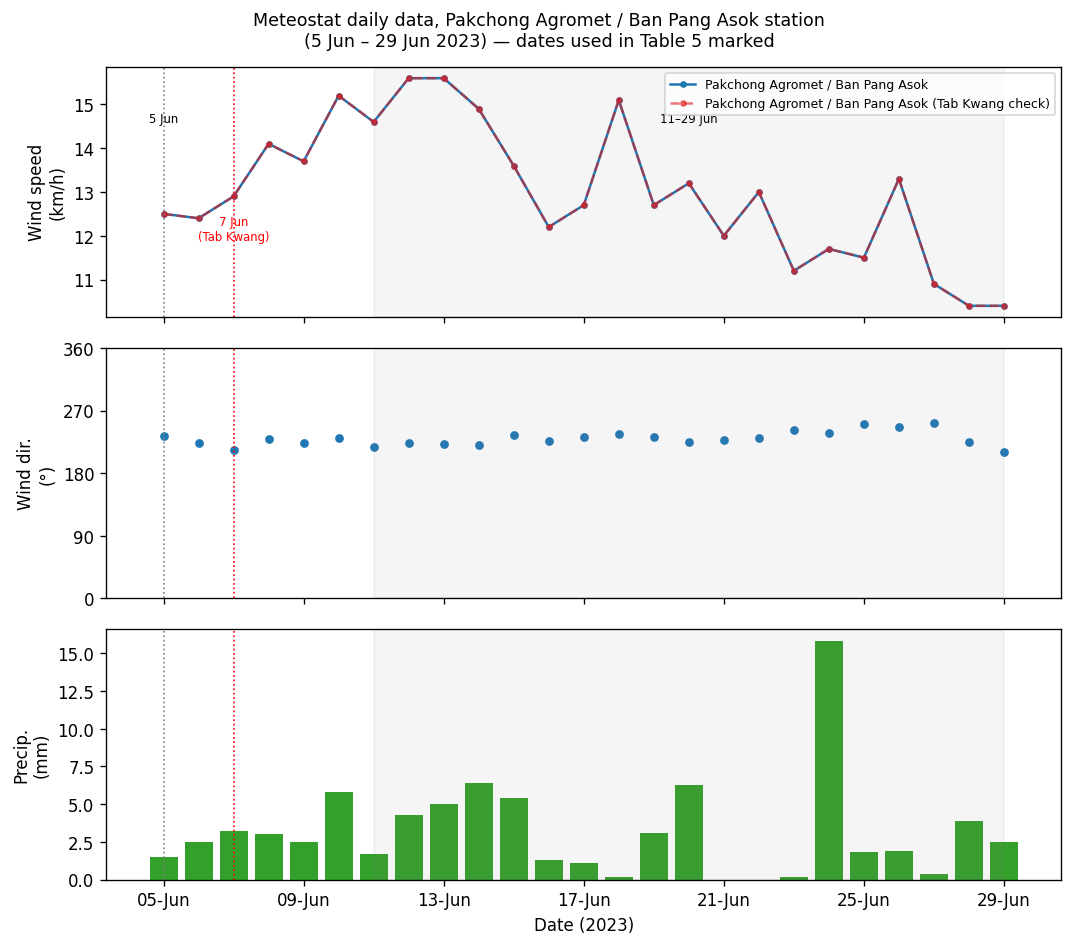

Saved figure_meteostat_example.svg and figure_meteostat_example.png


In [9]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: 4 - Meteostat example figure (for the manuscript comment requesting a
# sample Meteostat visualization with the exact dates/times used in the analysis)
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

# Panel 1: mean wind speed
axes[0].plot(centroid_data.index, centroid_data['wspd'], marker='o', ms=3,
             color='#1f78b4', label=centroid_station_name)
axes[0].plot(tk_data.index, tk_data['wspd'], marker='o', ms=3, linestyle='--',
             color='#e31a1c', alpha=0.6, label=f"{tk_station_name} (Tab Kwang check)")
axes[0].set_ylabel('Wind speed\n(km/h)')
axes[0].legend(fontsize=7.5, loc='upper right')

# Panel 2: mean wind direction
axes[1].scatter(centroid_data.index, centroid_data['wdir'], s=18, color='#1f78b4')
axes[1].set_ylabel('Wind dir.\n(\u00b0)')
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])

# Panel 3: precipitation
axes[2].bar(centroid_data.index, centroid_data['prcp'], width=0.8, color='#33a02c')
axes[2].set_ylabel('Precip.\n(mm)')
axes[2].set_xlabel('Date (2023)')

# Highlight the three reference dates/periods used in Table 5
for ax in axes:
    ax.axvline(pd.Timestamp('2023-06-05'), color='gray', linestyle=':', linewidth=1)
    ax.axvline(pd.Timestamp('2023-06-07'), color='red', linestyle=':', linewidth=1)
    ax.axvspan(pd.Timestamp('2023-06-11'), pd.Timestamp('2023-06-29'), color='gray', alpha=0.08)

axes[0].annotate('5 Jun', (pd.Timestamp('2023-06-05'), axes[0].get_ylim()[1]*0.92),
                  fontsize=7, ha='center')
axes[0].annotate('7 Jun\n(Tab Kwang)', (pd.Timestamp('2023-06-07'), axes[0].get_ylim()[1]*0.75),
                  fontsize=7, ha='center', color='red')
axes[0].annotate('11\u201329 Jun', (pd.Timestamp('2023-06-20'), axes[0].get_ylim()[1]*0.92),
                  fontsize=7, ha='center')

axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig.suptitle(f"Meteostat daily data, {centroid_station_name} station\n"
             f"({centroid_data.index.min().strftime('%-d %b')} \u2013 "
             f"{centroid_data.index.max().strftime('%-d %b %Y')}) \u2014 dates used in Table 5 marked",
             fontsize=10.5)
plt.tight_layout()
plt.savefig('figure_meteostat_example.svg', format='svg', bbox_inches='tight')
plt.savefig('figure_meteostat_example.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved figure_meteostat_example.svg and figure_meteostat_example.png")


## ดาวน์โหลดผลลัพธ์

In [10]:
# SCRIPT: Paper1_Table5_meteorological_context.ipynb
# SECTION: Download output
from google.colab import files as gfiles
for f in ['Table5_meteorological_context.xlsx', 'figure_meteostat_example.png', 'figure_meteostat_example.svg']:
    gfiles.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>